In [1]:
jsonl_path = "our_sec.jsonl"

import json
import os
import pandas as pd
import numpy as np

df = pd.read_json(jsonl_path, lines=True)
# drop duplicates
df = df.drop_duplicates(subset=["vuln_id"])
# remove nans from cwe_id
df = df[~df["cwe_id"].isna()]
# remove nans from cve_id
df = df[~df["score"].isna()]
# osv
df = df[df["dataset"] == "osv"]

In [2]:
def get_cwe(x):
    try:
        cwe_set = eval(x)
        if len(cwe_set) > 1:
            print(f"Warning: multiple CWEs found for {x}")
            return None
        else:
            return cwe_set.pop()
    except:
        return None

df["cwe"] = df["cwe_id"].apply(get_cwe)
df["cwe"]

0      CWE-611
1      CWE-200
2       CWE-74
3      CWE-400
4      CWE-125
        ...   
820     CWE-59
821    CWE-190
822    CWE-611
823     CWE-79
824    CWE-369
Name: cwe, Length: 792, dtype: object

In [13]:
def get_file_extension(files: set):
    files = list(files.keys())
    file = files[0]
    return file.split(".")[-1] if "." in file else None

df["file_extension"] = df["files"].apply(lambda x: get_file_extension(x))
df["file_extension"].value_counts()

file_extension
cc        175
php       166
js        152
java       54
py         53
go         42
ts         22
rs         21
rb         19
h          15
cpp        10
md          8
xml         7
c           5
html        5
json        5
cs          5
yml         4
coffee      3
mjs         2
jelly       2
twig        1
yaml        1
vue         1
toml        1
gradle      1
ejs         1
groovy      1
htm         1
vm          1
erb         1
tsx         1
dist        1
rabl        1
kt          1
x           1
jst         1
Name: count, dtype: int64

In [18]:
def filter_by_file_extension(df, supported_file_extensions):
    return df[df["file_extension"].isin(supported_file_extensions)]

df = filter_by_file_extension(df, ['java', 'ts', 'php', 'js', 'cc', 'py', 'go', 'kt', 'rb', 'rs',
       'cs', 'cpp', 'c', 'html', 'xml'])
print(df.shape)
# remove duplicates
df = df.drop_duplicates(subset=["vuln_id"])
print(df.shape)

(737, 26)
(737, 26)


In [19]:
# Save the DataFrame to a jsonl file
output_path = "our_sec_cleaned.jsonl"

with open(output_path, "w") as f:
    for record in df.to_dict(orient="records"):
        json.dump(record, f)
        f.write("\n")


Text(0, 0.5, 'Security Weakness (CWE)')

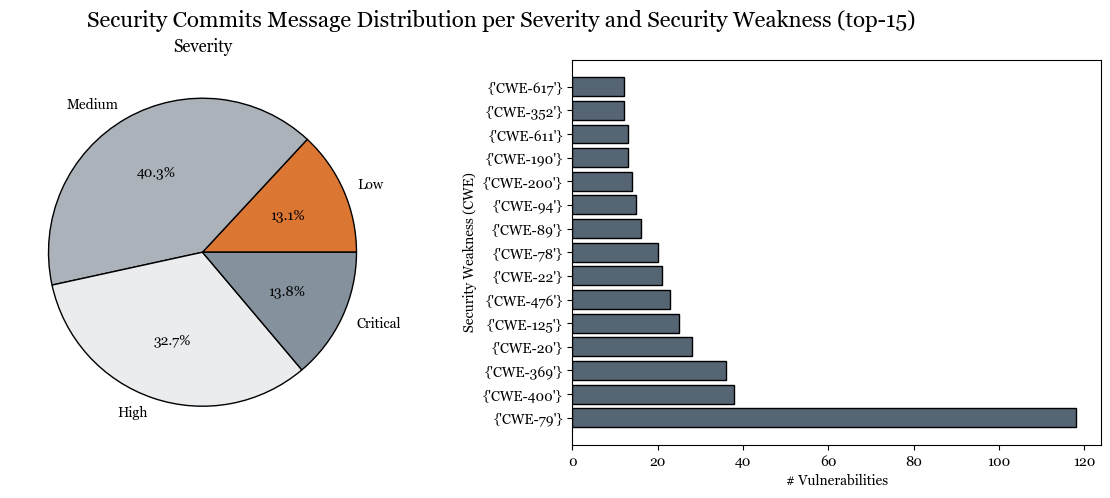

In [17]:
score = {'Low': 0, 'Medium': 0, 'High': 0, 'Critical': 0}
for sc in df.drop_duplicates(subset=['vuln_id'], keep="first")['score']:
    if sc >= 0.1 and sc <= 3.9:
        score['Low'] += 1
    elif sc >= 4.0 and sc <= 6.9:
        score['Medium'] += 1
    elif sc >= 7.0 and sc <= 8.9:
        score['High'] +=1 
    elif sc >= 9.0 and sc <= 10.0:
        score['Critical'] += 1

cwes_list = {}
for index, row in df.iterrows():
    cwe_id = row["cwe_id"]
    if cwe_id not in cwes_list:
        cwes_list[cwe_id] = 1
    else:
        cwes_list[cwe_id] += 1
df_sorted_cwes_list = pd.DataFrame(cwes_list.items(), columns=['cwe_id', 'count']).sort_values('count', ascending=False)
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "Georgia"

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Security Commits Message Distribution per Severity and Security Weakness (top-15)', size=16)

# score dist
ax1.pie(np.array(list(score.values())), 
        labels=list(score.keys()), 
        colors=['#DC7633', '#ABB2B9', '#EAECEE', '#85929E'],
        wedgeprops = {"edgecolor" : "black",
                      'linewidth': 1,
                      'antialiased': True}, 
        autopct='%.1f%%')
ax1.set_title('Severity')

# cwe dist
ax2.barh(list(df_sorted_cwes_list['cwe_id'].values)[0:15], 
        list(df_sorted_cwes_list['count'].values)[0:15],
        edgecolor='black',
        color='#566573')

ax2.set_xlabel("# Vulnerabilities")
ax2.set_ylabel("Security Weakness (CWE)")